# M5 conformal percentile selection with LINEX

This notebook builds a single LightGBM Tweedie model on M5, calibrates conformal prediction intervals, and then uses cross-validation to choose a per-series forecast among:

- the mean forecast,
- or one of the conformal high-percentile forecasts at levels `10, 20, 30, 40, 50, 60, 70`.

The selection is done only for the top 10% of `unique_id`s ranked by mean daily sales over a period that ends before the cross-validation windows start.

All helper logic for ranking, LINEX selection, and plotting lives inside this notebook; no `mlforecast` source files are modified.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lightgbm as lgb

from datasetsforecast.m5 import M5
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean
from mlforecast.utils import PredictionIntervals
from utilsforecast.losses import linex


In [13]:
# Experiment settings
H = 28
TEST_H = 28
CV_WINDOWS = 3
PI_WINDOWS = 3
LEVELS = [10, 20, 30, 40, 50, 60, 70]
LINEX_ALPHA = -0.25
TOP_SHARE = 0.10
RANK_LOOKBACK = 180
MIN_HISTORY = 500
MAX_IDS = 100  # set to an int for a quicker local run
PLOT_N_IDS = 25
NUM_THREADS = -1

DATE_FEATURES = ['dayofweek', 'week', 'month', 'day', 'dayofyear']
BASE_LAGS = [1, 7, 14, 28, 56]
MODEL_NAME = 'lgb_tweedie'

assert H == TEST_H, 'This notebook keeps CV horizon and final test horizon aligned.'


## LINEX sign note

`utilsforecast.losses.linex` defines the forecast error as `y_hat - y`.

- `a > 0` penalizes under-forecasting more.
- `a < 0` penalizes over-forecasting more.

This notebook uses a negative `LINEX_ALPHA` because that was the requested setup. If you want the selection step to prefer upper forecasts more aggressively, flip the sign.

In [14]:
def encode_categorical(series):
    return pd.factorize(series.astype('string').fillna('__missing__'))[0].astype('int32')


# Load M5 (downloads on first use if not already present in ./data)
Y_df, X_df, S_df = M5.load('data')
Y_df = Y_df[['unique_id', 'ds', 'y']].copy()
X_df = X_df.copy()
S_df = S_df.copy()

Y_df['ds'] = pd.to_datetime(Y_df['ds'])
X_df['ds'] = pd.to_datetime(X_df['ds'])

static_cols = ['unique_id', 'store_id', 'dept_id', 'cat_id', 'state_id', 'item_id']
meta_df = S_df[[c for c in static_cols if c in S_df.columns]].copy()

for raw_col, code_col in [
    ('store_id', 'store_code'),
    ('dept_id', 'dept_code'),
    ('cat_id', 'cat_code'),
    ('state_id', 'state_code'),
    ('item_id', 'item_code'),
]:
    if raw_col in meta_df.columns:
        meta_df[code_col] = encode_categorical(meta_df[raw_col])

snap_cols = [c for c in ['snap_CA', 'snap_TX', 'snap_WI'] if c in X_df.columns]
X_df['snap_active'] = X_df[snap_cols].fillna(0).max(axis=1).astype('int8') if snap_cols else 0

event_name_cols = [c for c in ['event_name_1', 'event_name_2'] if c in X_df.columns]
event_type_cols = [c for c in ['event_type_1', 'event_type_2'] if c in X_df.columns]
for raw_col in [*event_name_cols, *event_type_cols]:
    X_df[f'{raw_col}_code'] = encode_categorical(X_df[raw_col])

if event_name_cols:
    X_df['is_event_day'] = X_df[event_name_cols].notna().any(axis=1).astype('int8')
else:
    X_df['is_event_day'] = 0

X_df = X_df.sort_values(['unique_id', 'ds']).reset_index(drop=True)
if 'sell_price' in X_df.columns:
    prev_price = X_df.groupby('unique_id')['sell_price'].shift(1)
    X_df['sell_price_change_1'] = (X_df['sell_price'] - prev_price).fillna(0.0)
    X_df['sell_price_pct_change_1'] = (
        (X_df['sell_price_change_1'] / prev_price.replace(0, np.nan))
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )
    X_df['price_drop_flag'] = (X_df['sell_price_change_1'] < 0).astype('int8')
else:
    X_df['sell_price_change_1'] = 0.0
    X_df['sell_price_pct_change_1'] = 0.0
    X_df['price_drop_flag'] = 0

dynamic_cols = ['unique_id', 'ds', 'snap_active', 'is_event_day', *snap_cols]
optional_dynamic_cols = [
    c
    for c in [
        'sell_price',
        'sell_price_change_1',
        'sell_price_pct_change_1',
        'price_drop_flag',
        'event_name_1_code',
        'event_name_2_code',
        'event_type_1_code',
        'event_type_2_code',
    ]
    if c in X_df.columns
]
dynamic_cols.extend(optional_dynamic_cols)

df = (
    Y_df
    .merge(X_df[dynamic_cols], on=['unique_id', 'ds'], how='left')
    .merge(
        meta_df[[c for c in ['unique_id', 'store_code', 'dept_code', 'cat_code', 'state_code', 'item_code'] if c in meta_df.columns]],
        on='unique_id',
        how='left',
    )
)

required_history = max(MIN_HISTORY, TEST_H + CV_WINDOWS * H + RANK_LOOKBACK + 84)
counts = df.groupby('unique_id').size().rename('n_obs')
eligible_ids = counts[counts >= required_history].index.tolist()
if MAX_IDS is not None:
    eligible_ids = eligible_ids[:MAX_IDS]

df = df[df['unique_id'].isin(eligible_ids)].copy()
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

STATIC_FEATURES = [
    c
    for c in ['store_code', 'dept_code', 'cat_code', 'state_code', 'item_code']
    if c in df.columns
]

print(f'rows: {len(df):,}')
print(f'unique_id count: {df["unique_id"].nunique():,}')
print(f'min/median/max history: {counts.loc[eligible_ids].min()} / {int(counts.loc[eligible_ids].median())} / {counts.loc[eligible_ids].max()}')
print(f'static features: {STATIC_FEATURES}')
print(f'dynamic feature columns: {[c for c in dynamic_cols if c not in ["unique_id", "ds"]]}')

df.head()


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_82978/2914555936.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prev_price = X_df.groupby('unique_id')['sell_price'].shift(1)
/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_82978/2914555936.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby('unique_id').size().rename('n_obs')


rows: 181,878
unique_id count: 100
min/median/max history: 1151 / 1964 / 1969
static features: ['store_code', 'dept_code', 'cat_code', 'state_code', 'item_code']
dynamic feature columns: ['snap_active', 'is_event_day', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'sell_price_change_1', 'sell_price_pct_change_1', 'price_drop_flag', 'event_name_1_code', 'event_name_2_code', 'event_type_1_code', 'event_type_2_code']


,unique_id,ds,y,snap_active,is_event_day,snap_CA,snap_TX,snap_WI,sell_price,sell_price_change_1,...,price_drop_flag,event_name_1_code,event_name_2_code,event_type_1_code,event_type_2_code,store_code,dept_code,cat_code,state_code,item_code
0,FOODS_1_001_CA_1,2011-01-29,3.0,0,1,0,0,0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,FOODS_1_001_CA_1,2011-01-30,0.0,0,1,0,0,0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,FOODS_1_001_CA_1,2011-01-31,0.0,0,1,0,0,0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,FOODS_1_001_CA_1,2011-02-01,1.0,1,1,1,1,0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,FOODS_1_001_CA_1,2011-02-02,4.0,1,1,1,0,1,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
def make_holdout_split(frame, h):
    test_df = frame.groupby('unique_id', group_keys=False).tail(h).copy()
    train_df = frame.drop(index=test_df.index).copy()
    return train_df, test_df


def build_ranking_frame(frame, h, n_windows, lookback=None):
    holdout = h * n_windows
    pieces = []
    for _, grp in frame.groupby('unique_id', sort=False):
        grp = grp.sort_values('ds')
        before_cv = grp.iloc[:-holdout] if len(grp) > holdout else grp.iloc[0:0]
        if lookback is not None and len(before_cv) > lookback:
            before_cv = before_cv.tail(lookback)
        pieces.append(before_cv)
    return pd.concat(pieces, ignore_index=True)


def build_lag_transforms(include_yearly_lag):
    lag_transforms = {
        1: [
            ExpandingMean(),
            RollingMean(3),
            RollingMean(7),
            RollingMean(14),
            RollingMean(28),
            RollingMean(56),
            RollingMean(84),
        ],
        7: [RollingMean(2), RollingMean(4), RollingMean(8)],
        28: [RollingMean(2), RollingMean(4)],
    }
    if include_yearly_lag:
        lag_transforms[364] = [RollingMean(7)]
    return lag_transforms


def build_feature_config(train_df):
    min_history = int(train_df.groupby('unique_id').size().min())
    include_yearly_lag = min_history > 364
    lags = BASE_LAGS.copy()
    if include_yearly_lag:
        lags.append(364)
    return {
        'min_history': min_history,
        'include_yearly_lag': include_yearly_lag,
        'lags': lags,
        'lag_transforms': build_lag_transforms(include_yearly_lag),
    }


def build_model():
    return lgb.LGBMRegressor(
        objective='tweedie',
        tweedie_variance_power=1.3,
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=255,
        min_child_samples=50,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=0,
        verbosity=-1,
        n_jobs=NUM_THREADS,
    )


def build_forecaster(train_df):
    feature_cfg = build_feature_config(train_df)
    fcst = MLForecast(
        models={MODEL_NAME: build_model()},
        freq='D',
        lags=feature_cfg['lags'],
        lag_transforms=feature_cfg['lag_transforms'],
        date_features=DATE_FEATURES,
        num_threads=NUM_THREADS,
    )
    return fcst, feature_cfg


def get_future_exog(frame, static_features):
    reserved = {'unique_id', 'ds', 'y', *static_features}
    dynamic = [c for c in frame.columns if c not in reserved]
    return frame[['unique_id', 'ds', *dynamic]].copy()


def get_candidate_cols(model_name, levels):
    return [model_name, *[f'{model_name}-hi-{lv}' for lv in levels]]


def compute_linex_selection(cv_frame, candidate_cols, a):
    loss_df = linex(cv_frame.drop(columns='cutoff'), models=candidate_cols, a=a)
    selector = (
        loss_df.set_index('unique_id')[candidate_cols]
        .idxmin(axis=1)
        .rename('selected_column')
        .reset_index()
    )
    selector['selection_label'] = selector['selected_column'].map(
        lambda col: 'mean' if col == MODEL_NAME else col.replace(f'{MODEL_NAME}-hi-', 'hi-')
    )
    return loss_df, selector


def apply_selected_forecast(frame, selector, candidate_cols, output_col='selected_forecast'):
    out = frame.merge(selector[['unique_id', 'selected_column', 'selection_label']], on='unique_id', how='left')
    col_to_idx = {col: i for i, col in enumerate(candidate_cols)}
    idx = out['selected_column'].map(col_to_idx).to_numpy()
    values = out[candidate_cols].to_numpy()
    out[output_col] = values[np.arange(len(out)), idx]
    return out


def point_metrics(frame, pred_col, a):
    err = frame[pred_col] - frame['y']
    mae = np.abs(err).mean()
    rmse = np.sqrt(np.mean(np.square(err)))
    linex_df = linex(frame[['unique_id', 'y', pred_col]], models=[pred_col], a=a)
    linex_mean = linex_df[pred_col].mean()
    return {'mae': mae, 'rmse': rmse, 'linex': linex_mean}


def plot_selected_ids(eval_df, selector, rank_stats, model_col, plot_n=12):
    ids = rank_stats['unique_id'].head(plot_n).tolist()
    choice_map = selector.set_index('unique_id')['selection_label'].to_dict()
    mean_sales_map = rank_stats.set_index('unique_id')['mean_daily_sales'].to_dict()
    for uid in ids:
        uid_df = eval_df[eval_df['unique_id'] == uid].sort_values('ds')
        plt.figure(figsize=(13, 4))
        plt.plot(uid_df['ds'], uid_df['y'], label='truth', color='black', linewidth=2)
        plt.plot(uid_df['ds'], uid_df[model_col], label='mean forecast', color='C0', linewidth=2)
        plt.plot(uid_df['ds'], uid_df['selected_forecast'], label=f"selected ({choice_map.get(uid, 'mean')})", color='C3', linewidth=2)
        plt.title(f"{uid} | mean_daily_sales={mean_sales_map.get(uid, np.nan):.2f}")
        plt.xlabel('ds')
        plt.ylabel('sales')
        plt.legend()
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()


In [16]:
cv_train_df, final_test_df = make_holdout_split(df, TEST_H)
ranking_df = build_ranking_frame(cv_train_df, H, CV_WINDOWS, RANK_LOOKBACK)
rank_stats = (
    ranking_df.groupby('unique_id', as_index=False)['y']
    .mean()
    .rename(columns={'y': 'mean_daily_sales'})
    .sort_values('mean_daily_sales', ascending=False)
    .reset_index(drop=True)
)

n_top_ids = max(1, int(np.ceil(len(rank_stats) * TOP_SHARE)))
selected_ids = rank_stats.head(n_top_ids)['unique_id'].tolist()
selected_rank_stats = rank_stats[rank_stats['unique_id'].isin(selected_ids)].copy()

print(f'cv-train rows: {len(cv_train_df):,}')
print(f'final test rows: {len(final_test_df):,}')
print(f'ranking rows before CV starts: {len(ranking_df):,}')
print(f'top-share selected ids: {len(selected_ids):,}')
print(f'ranking period: {ranking_df["ds"].min().date()} -> {ranking_df["ds"].max().date()}')

selected_rank_stats.head(10)


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_82978/3207660567.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_df = frame.groupby('unique_id', group_keys=False).tail(h).copy()
/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_82978/3207660567.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, grp in frame.groupby('unique_id', sort=False):


cv-train rows: 179,078
final test rows: 2,800
ranking rows before CV starts: 18,000
top-share selected ids: 3,049
ranking period: 2015-09-02 -> 2016-02-28


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_82978/3146245519.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ranking_df.groupby('unique_id', as_index=False)['y']


,unique_id,mean_daily_sales
0,FOODS_1_004_WI_2,9.550000
1,FOODS_1_004_TX_1,6.405556
2,FOODS_1_004_WI_3,5.850000
3,FOODS_1_004_TX_3,5.522222
4,FOODS_1_004_CA_1,5.055555
5,FOODS_1_004_WI_1,4.188889
6,FOODS_1_004_CA_2,3.527778
7,FOODS_1_004_CA_3,3.527778
8,FOODS_1_005_CA_2,2.777778
9,FOODS_1_005_CA_3,2.377778


In [17]:
cv_fcst, cv_feature_cfg = build_forecaster(cv_train_df)
candidate_cols = get_candidate_cols(MODEL_NAME, LEVELS)

cv_results = cv_fcst.cross_validation(
    df=cv_train_df,
    n_windows=CV_WINDOWS,
    h=H,
    step_size=H,
    refit=True,
    static_features=STATIC_FEATURES,
    dropna=False,
    prediction_intervals=PredictionIntervals(
        n_windows=PI_WINDOWS,
        h=H,
        method='conformal_distribution',
    ),
    level=LEVELS,
)

cv_selected = cv_results[cv_results['unique_id'].isin(selected_ids)][['unique_id', 'ds', 'cutoff', 'y', *candidate_cols]].copy()

print(cv_feature_cfg)
print(f'cv rows kept for selection: {len(cv_selected):,}')
cv_selected.head()


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_82978/3207660567.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  min_history = int(train_df.groupby('unique_id').size().min())


{'min_history': 0, 'include_yearly_lag': False, 'lags': [1, 7, 14, 28, 56], 'lag_transforms': {1: [ExpandingMean(), RollingMean(window_size=3), RollingMean(window_size=7), RollingMean(window_size=14), RollingMean(window_size=28), RollingMean(window_size=56), RollingMean(window_size=84)], 7: [RollingMean(window_size=2), RollingMean(window_size=4), RollingMean(window_size=8)], 28: [RollingMean(window_size=2), RollingMean(window_size=4)]}}
cv rows kept for selection: 8,400


,unique_id,ds,cutoff,y,lgb_tweedie,lgb_tweedie-hi-10,lgb_tweedie-hi-20,lgb_tweedie-hi-30,lgb_tweedie-hi-40,lgb_tweedie-hi-50,lgb_tweedie-hi-60,lgb_tweedie-hi-70
0,FOODS_1_001_CA_1,2016-02-29,2016-02-28,1.0,0.504273,0.757729,1.011184,1.062939,1.114694,1.166449,1.218204,1.228212
1,FOODS_1_001_CA_1,2016-03-01,2016-02-28,0.0,0.563643,0.828603,1.093562,1.352951,1.612340,1.871729,2.131118,2.515920
2,FOODS_1_001_CA_1,2016-03-02,2016-02-28,1.0,0.670684,0.681552,0.692419,0.821853,0.951287,1.080721,1.210155,1.213052
3,FOODS_1_001_CA_1,2016-03-03,2016-02-28,0.0,0.732130,0.741650,0.751170,0.877676,1.004181,1.130687,1.257192,1.744154
4,FOODS_1_001_CA_1,2016-03-04,2016-02-28,0.0,0.941390,1.042065,1.142739,1.200254,1.257770,1.315285,1.372801,1.798699


In [18]:
cv_loss_df, selector_df = compute_linex_selection(cv_selected, candidate_cols, LINEX_ALPHA)
selection_counts = (
    selector_df['selection_label']
    .value_counts()
    .rename_axis('selected_forecast')
    .reset_index(name='n_unique_id')
)
selection_counts['share'] = selection_counts['n_unique_id'] / selection_counts['n_unique_id'].sum()

selection_counts


,selected_forecast,n_unique_id,share
0,mean,33,0.33
1,hi-10,24,0.24
2,hi-70,13,0.13
3,hi-20,11,0.11
4,hi-40,8,0.08
5,hi-60,6,0.06
6,hi-30,4,0.04
7,hi-50,1,0.01


In [19]:
final_fcst, final_feature_cfg = build_forecaster(cv_train_df)
future_exog = get_future_exog(final_test_df, STATIC_FEATURES)

final_fcst.fit(
    cv_train_df,
    static_features=STATIC_FEATURES,
    dropna=False,
    prediction_intervals=PredictionIntervals(
        n_windows=PI_WINDOWS,
        h=TEST_H,
        method='conformal_distribution',
    ),
)

test_preds = final_fcst.predict(h=TEST_H, X_df=future_exog, level=LEVELS)
test_eval = (
    final_test_df[final_test_df['unique_id'].isin(selected_ids)][['unique_id', 'ds', 'y']]
    .merge(test_preds, on=['unique_id', 'ds'], how='left')
)
test_eval = apply_selected_forecast(test_eval, selector_df, candidate_cols)

print(final_feature_cfg)
test_eval.head()


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_82978/3207660567.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  min_history = int(train_df.groupby('unique_id').size().min())


{'min_history': 0, 'include_yearly_lag': False, 'lags': [1, 7, 14, 28, 56], 'lag_transforms': {1: [ExpandingMean(), RollingMean(window_size=3), RollingMean(window_size=7), RollingMean(window_size=14), RollingMean(window_size=28), RollingMean(window_size=56), RollingMean(window_size=84)], 7: [RollingMean(window_size=2), RollingMean(window_size=4), RollingMean(window_size=8)], 28: [RollingMean(window_size=2), RollingMean(window_size=4)]}}


,unique_id,ds,y,lgb_tweedie,lgb_tweedie-lo-70,lgb_tweedie-lo-60,lgb_tweedie-lo-50,lgb_tweedie-lo-40,lgb_tweedie-lo-30,lgb_tweedie-lo-20,...,lgb_tweedie-hi-10,lgb_tweedie-hi-20,lgb_tweedie-hi-30,lgb_tweedie-hi-40,lgb_tweedie-hi-50,lgb_tweedie-hi-60,lgb_tweedie-hi-70,selected_column,selection_label,selected_forecast
0,FOODS_1_001_CA_1,2016-05-23,3.0,0.581189,-0.833698,-0.795940,-0.575589,-0.355239,-0.134889,0.085462,...,0.829052,1.076915,1.297266,1.517616,1.737966,1.958317,1.996075,lgb_tweedie-hi-20,hi-20,1.076915
1,FOODS_1_001_CA_1,2016-05-24,0.0,0.843033,0.258438,0.279390,0.292741,0.306092,0.319443,0.332794,...,1.098153,1.353272,1.366623,1.379974,1.393325,1.406677,1.427628,lgb_tweedie-hi-20,hi-20,1.353272
2,FOODS_1_001_CA_1,2016-05-25,0.0,0.759233,0.221923,0.297981,0.330965,0.363949,0.396933,0.429917,...,0.923891,1.088549,1.121533,1.154517,1.187501,1.220485,1.296543,lgb_tweedie-hi-20,hi-20,1.088549
3,FOODS_1_001_CA_1,2016-05-26,0.0,0.692810,-0.053255,-0.039320,0.006570,0.052460,0.098350,0.144240,...,0.967096,1.241381,1.287271,1.333161,1.379050,1.424940,1.438876,lgb_tweedie-hi-20,hi-20,1.241381
4,FOODS_1_001_CA_1,2016-05-27,6.0,0.771802,-0.735504,-0.169589,-0.149205,-0.128821,-0.108437,-0.088053,...,1.201729,1.631656,1.652040,1.672424,1.692808,1.713192,2.279107,lgb_tweedie-hi-20,hi-20,1.631656


In [20]:
metrics_df = pd.DataFrame([
    {'forecast': 'mean', **point_metrics(test_eval, MODEL_NAME, LINEX_ALPHA)},
    {'forecast': 'selected', **point_metrics(test_eval, 'selected_forecast', LINEX_ALPHA)},
]).round(4)

metrics_df


,forecast,mae,rmse,linex
0,mean,1.1373,2.1418,2.1085
1,selected,1.4005,2.7530,1.0536


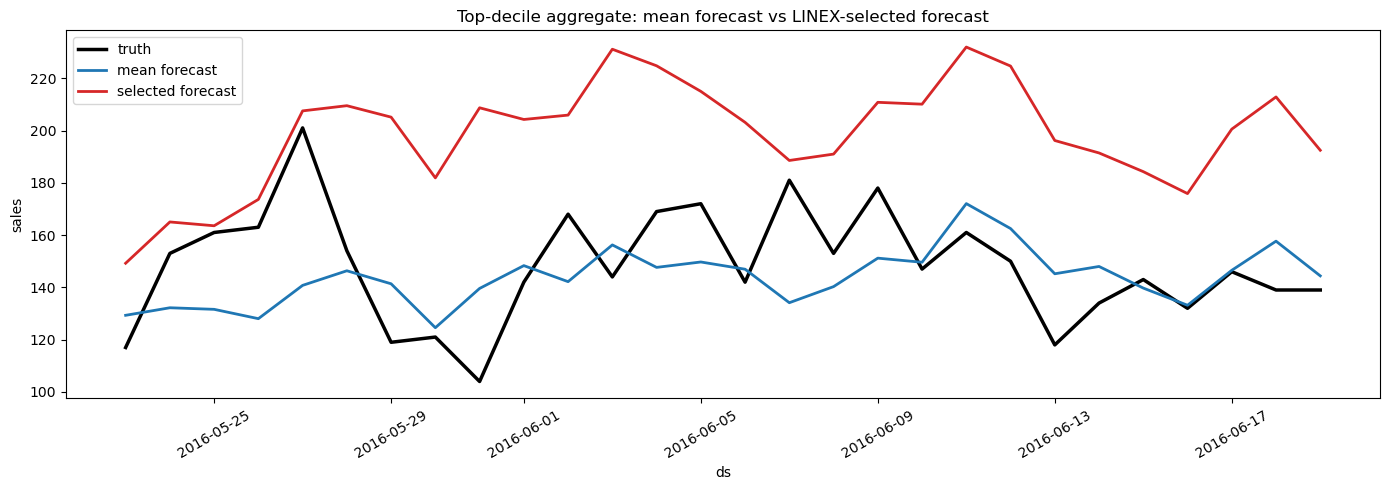

In [21]:
aggregate_eval = (
    test_eval.groupby('ds', as_index=False)[['y', MODEL_NAME, 'selected_forecast']]
    .sum()
    .rename(columns={MODEL_NAME: 'mean_forecast'})
)

plt.figure(figsize=(14, 5))
plt.plot(aggregate_eval['ds'], aggregate_eval['y'], label='truth', color='black', linewidth=2.5)
plt.plot(aggregate_eval['ds'], aggregate_eval['mean_forecast'], label='mean forecast', color='C0', linewidth=2)
plt.plot(aggregate_eval['ds'], aggregate_eval['selected_forecast'], label='selected forecast', color='C3', linewidth=2)
plt.title('Top-decile aggregate: mean forecast vs LINEX-selected forecast')
plt.xlabel('ds')
plt.ylabel('sales')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


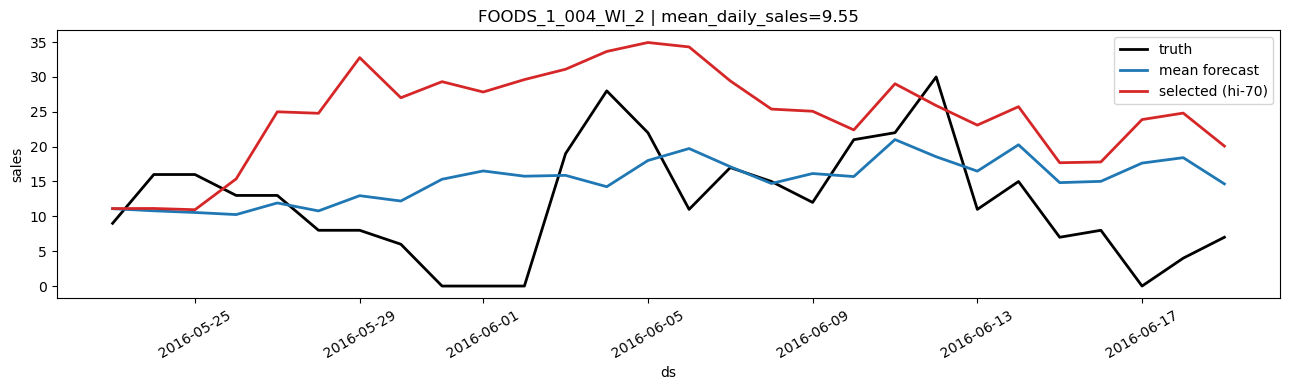

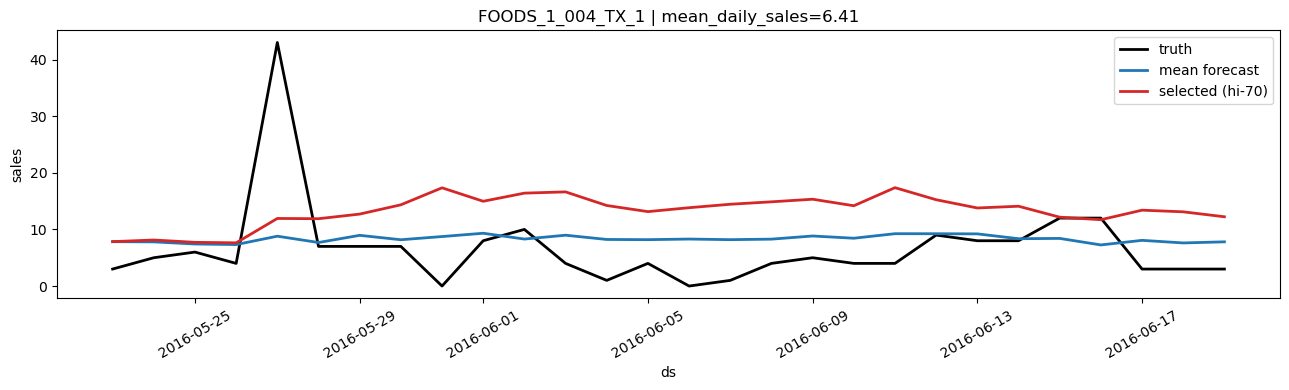

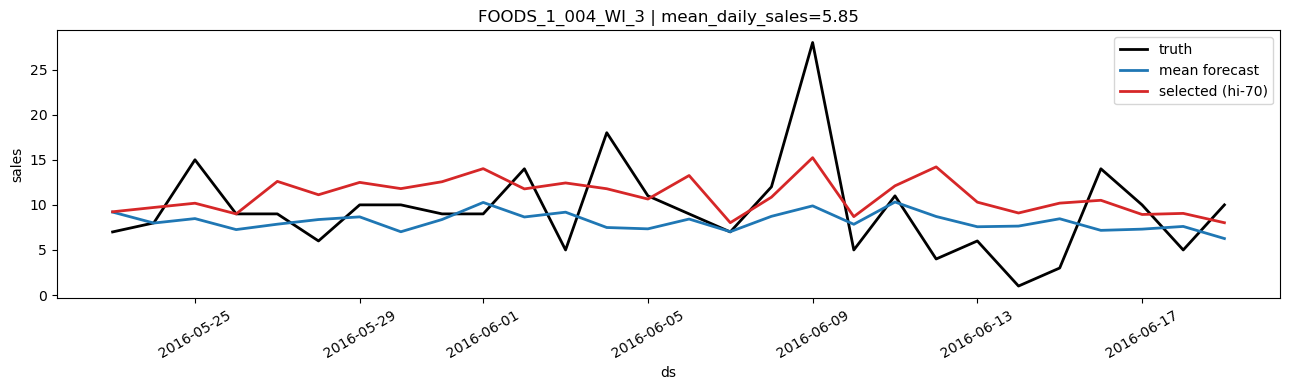

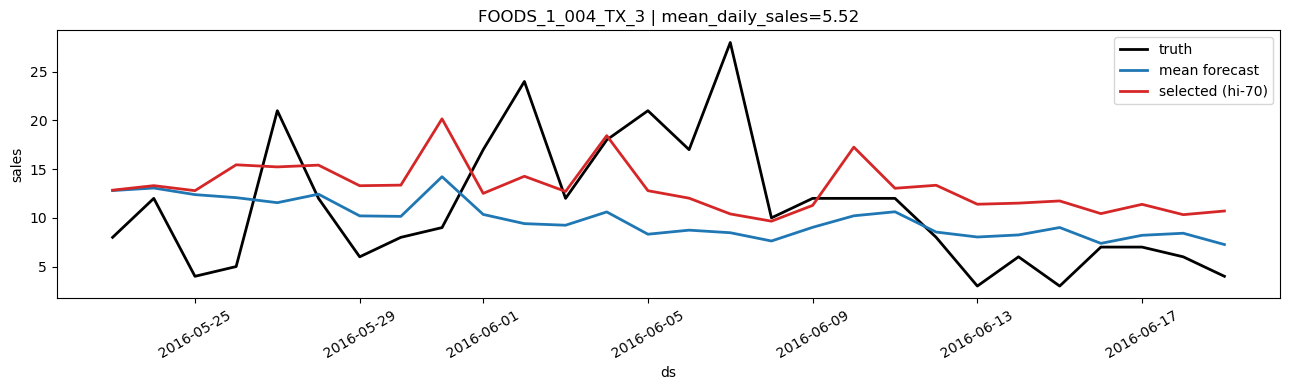

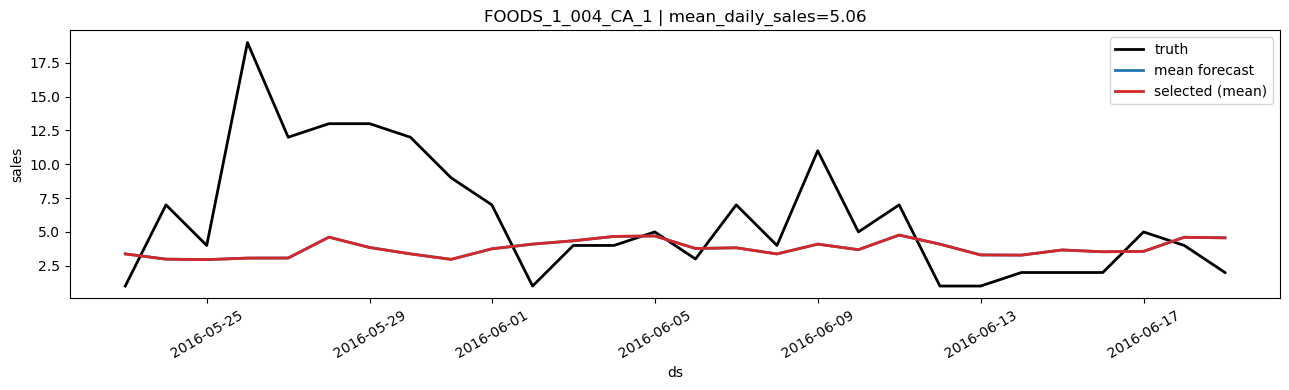

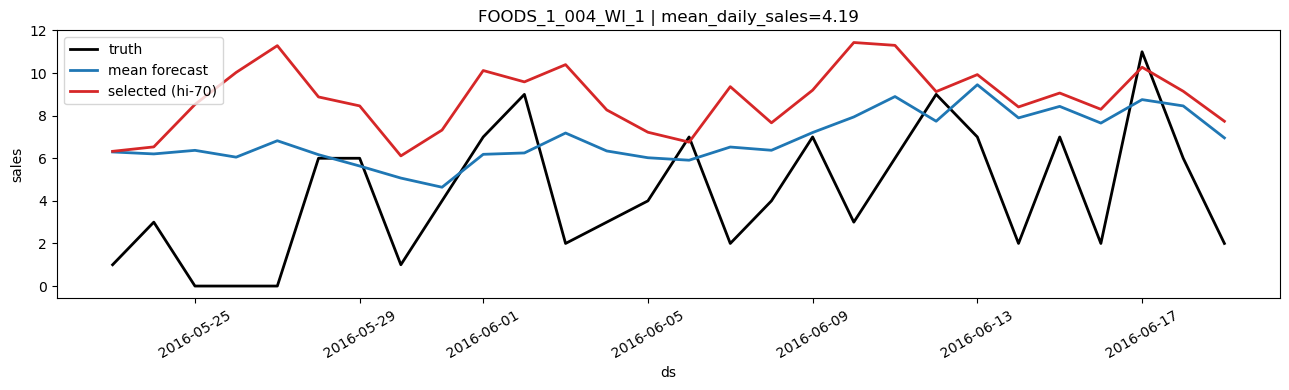

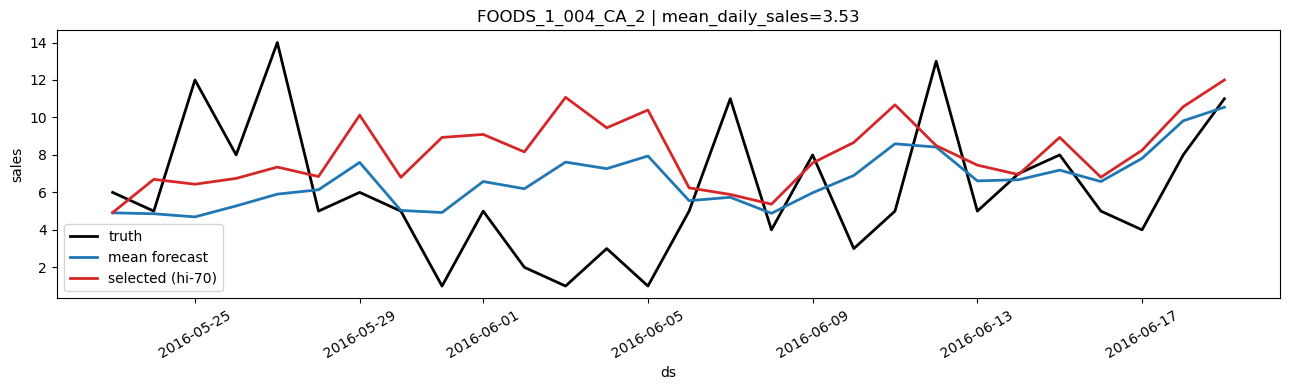

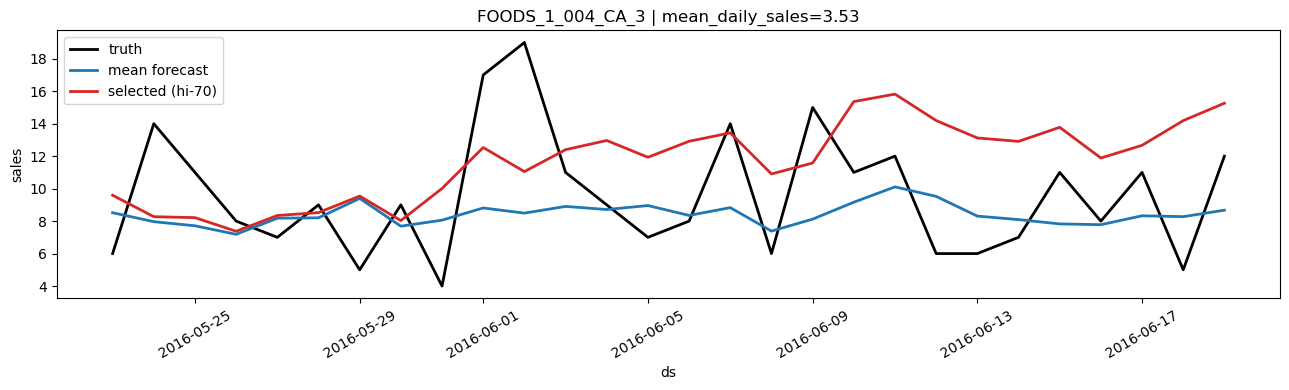

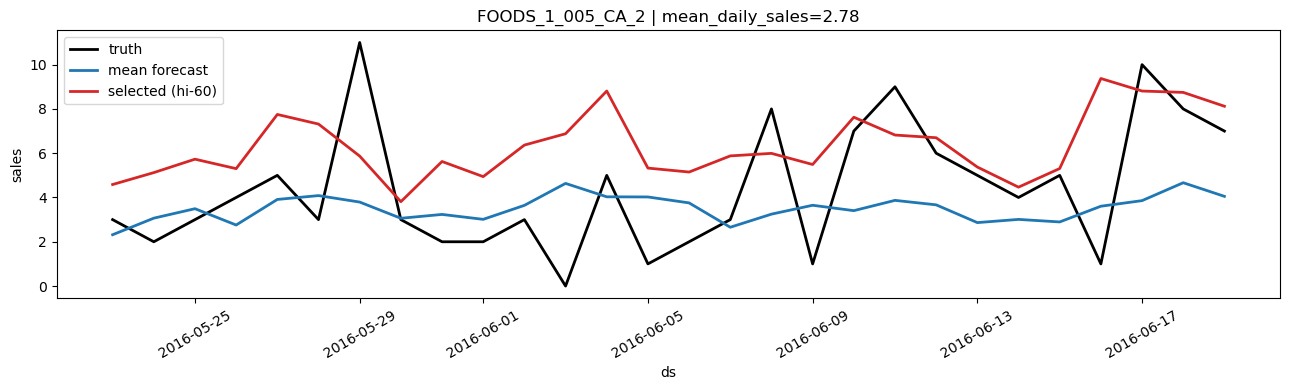

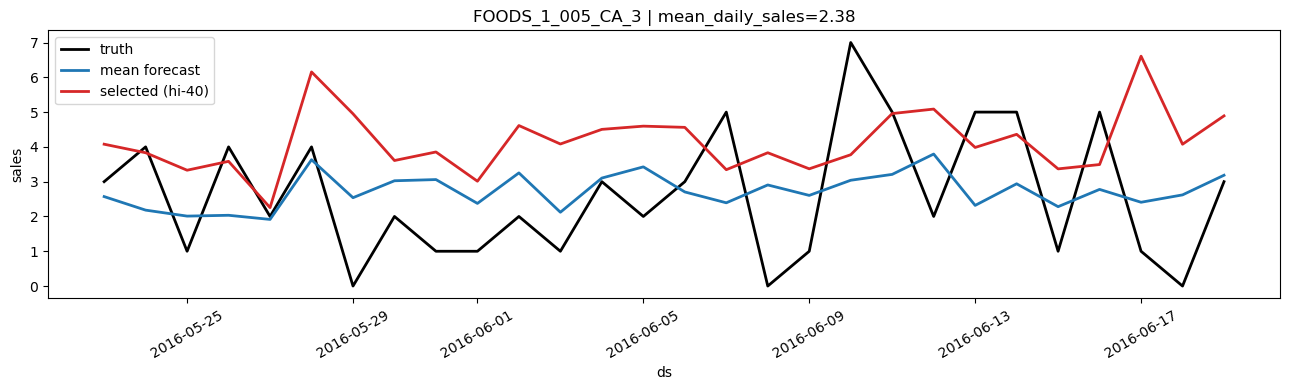

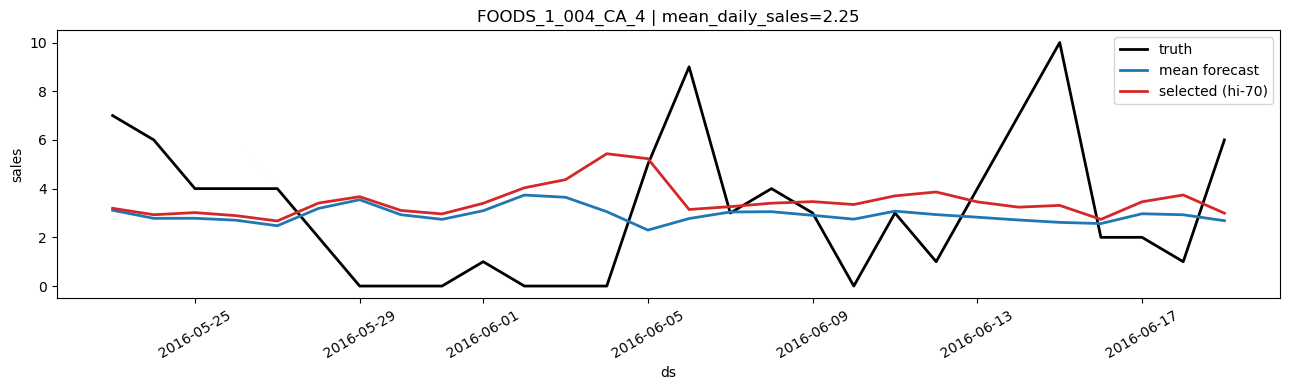

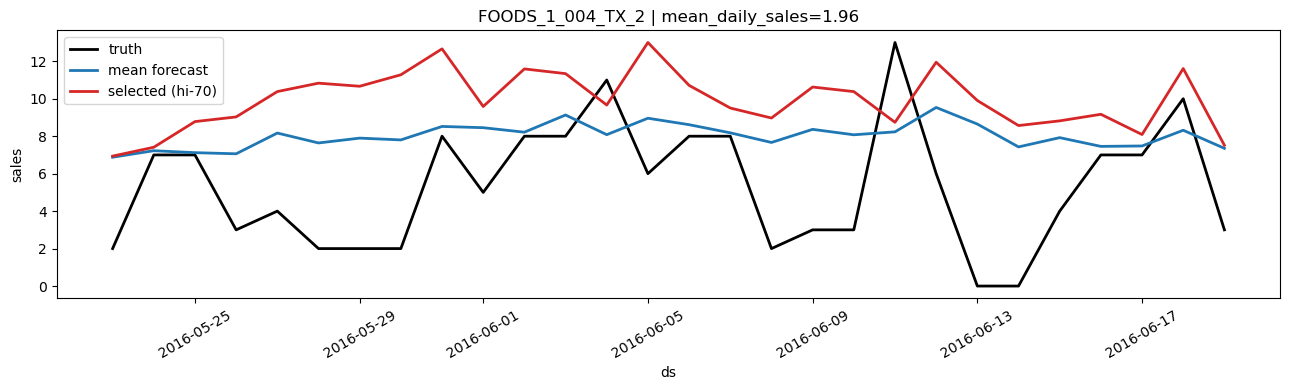

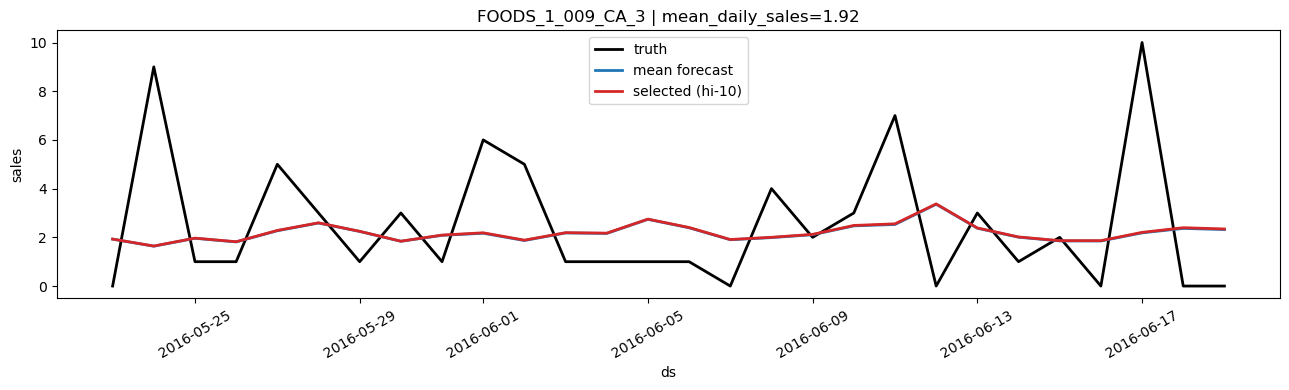

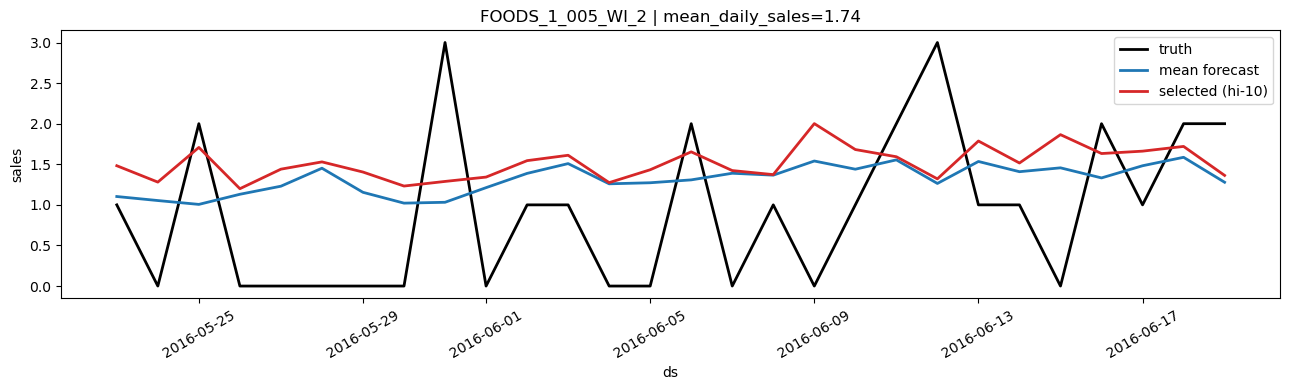

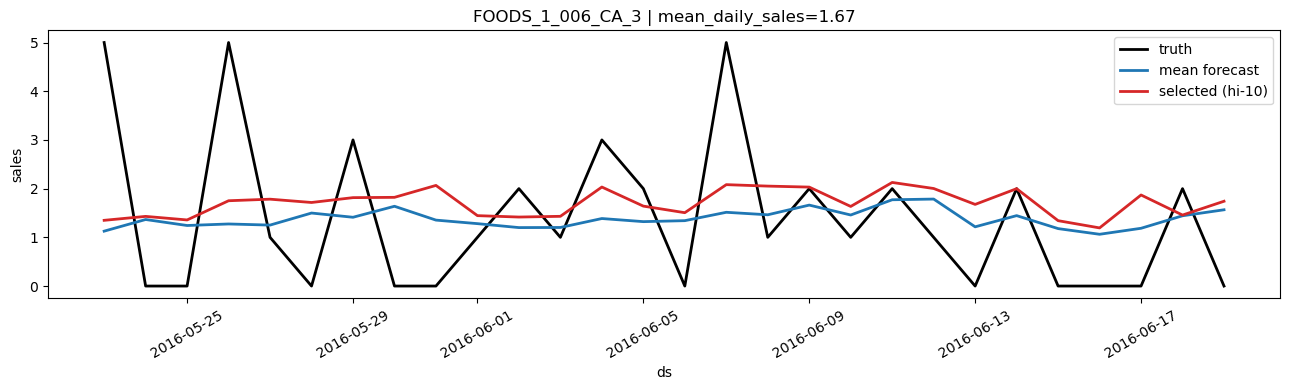

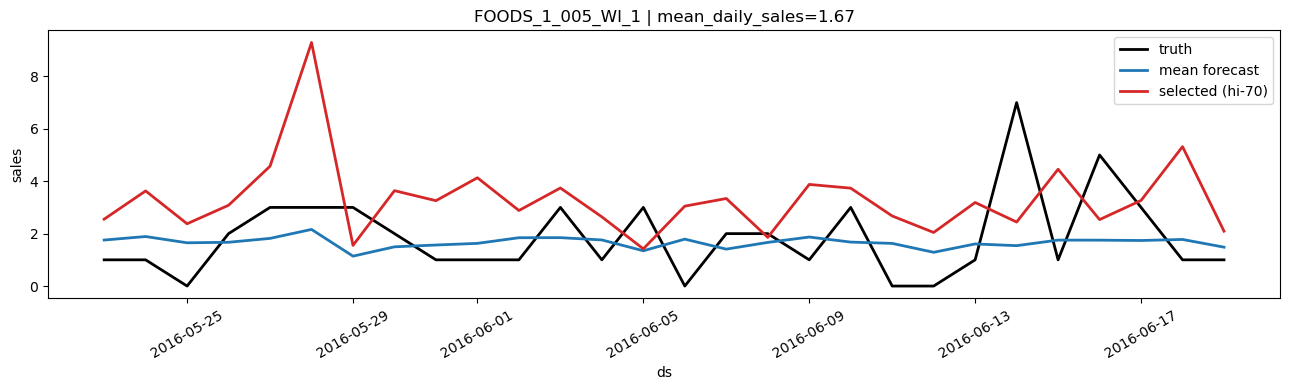

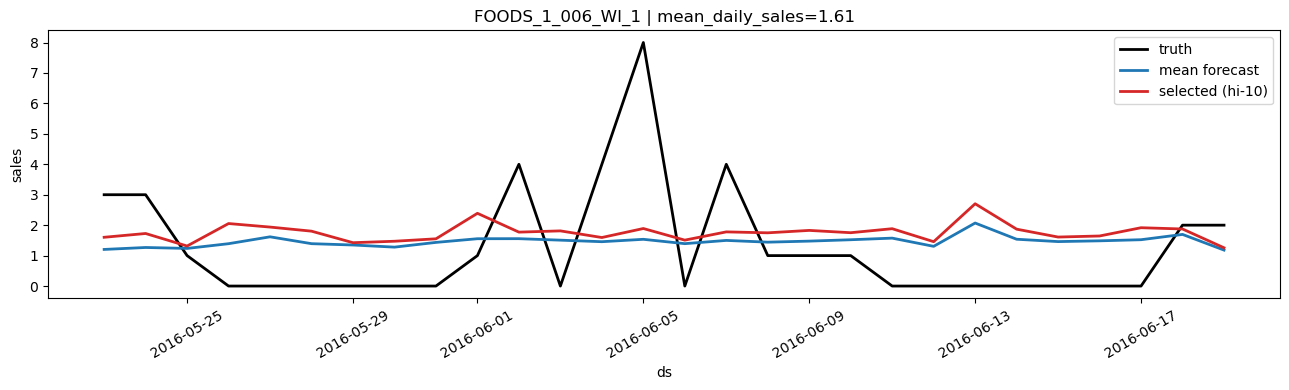

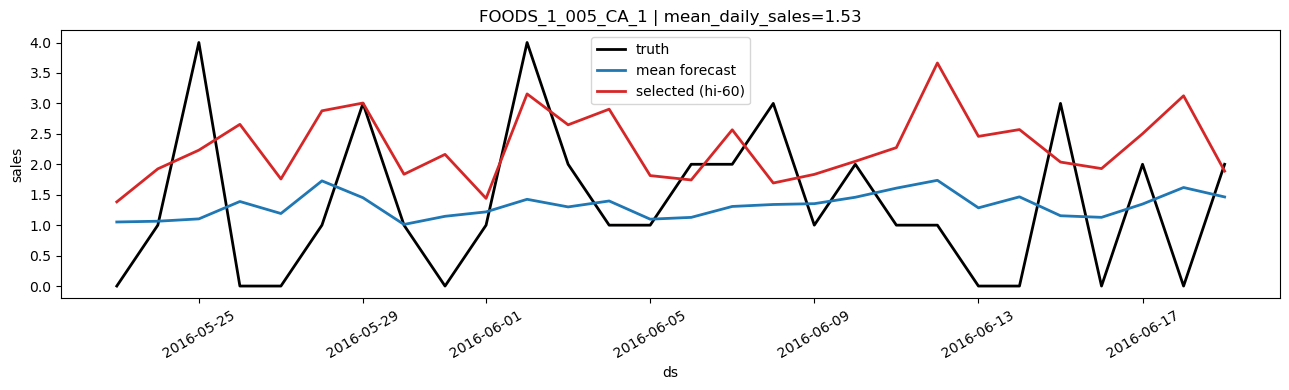

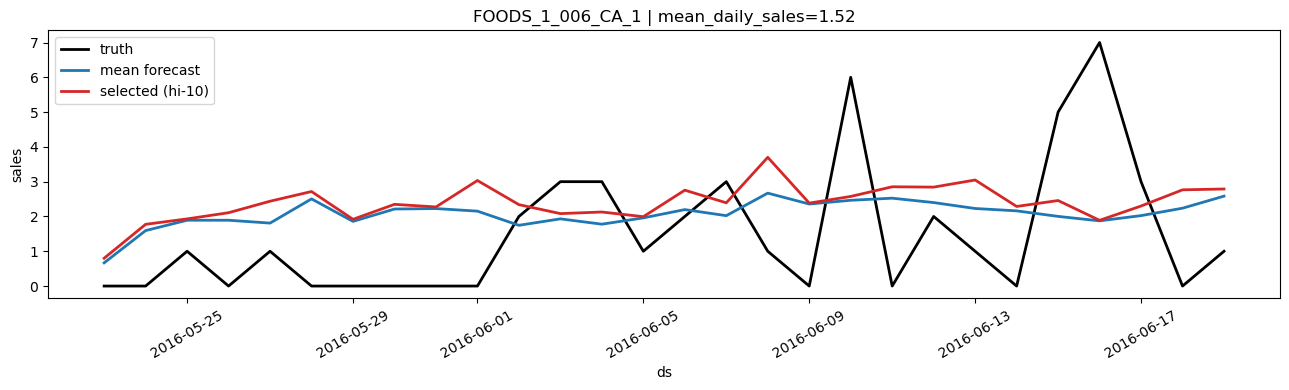

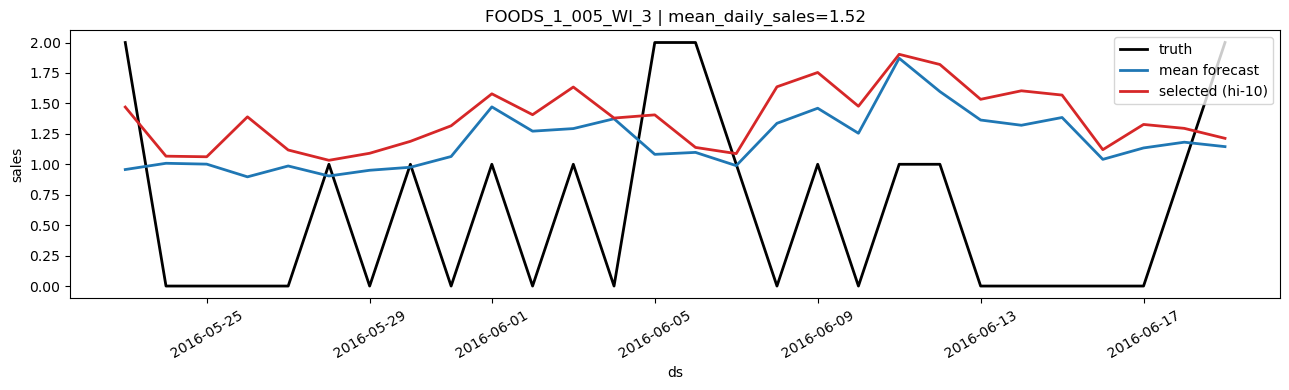

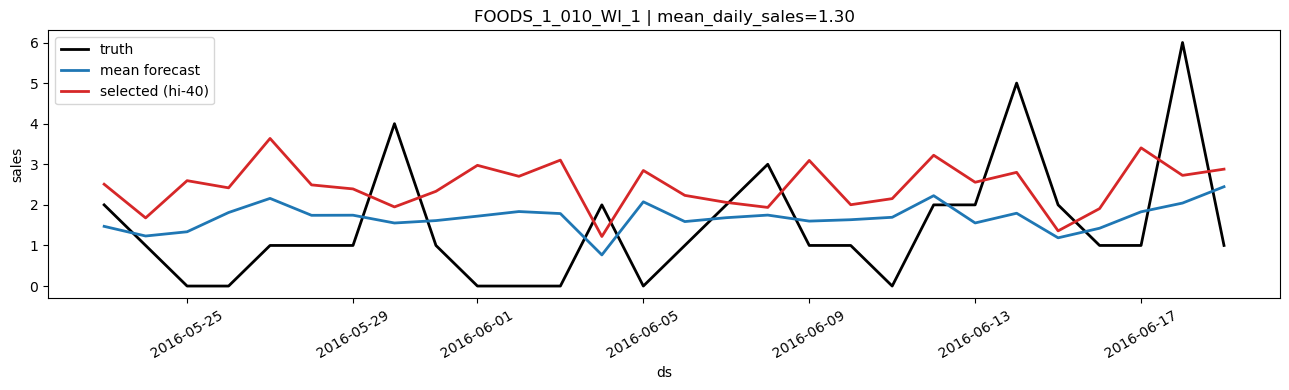

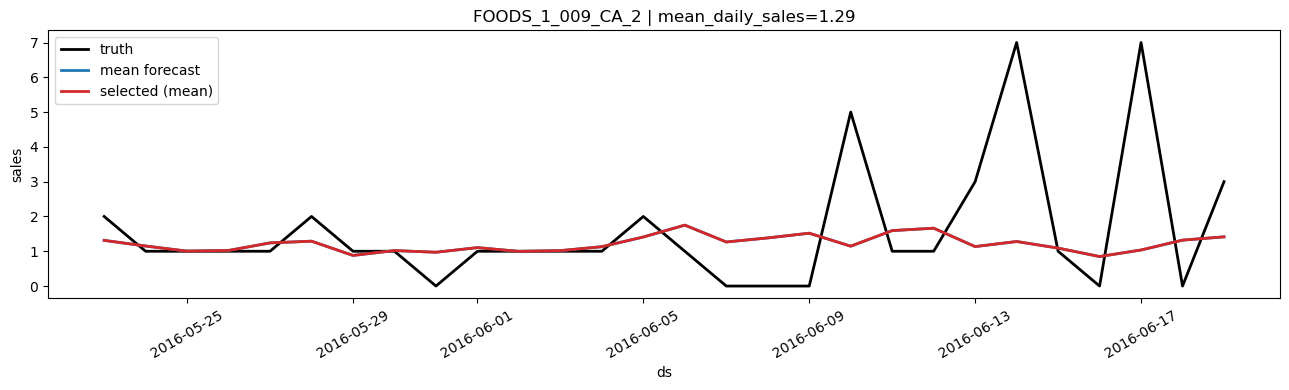

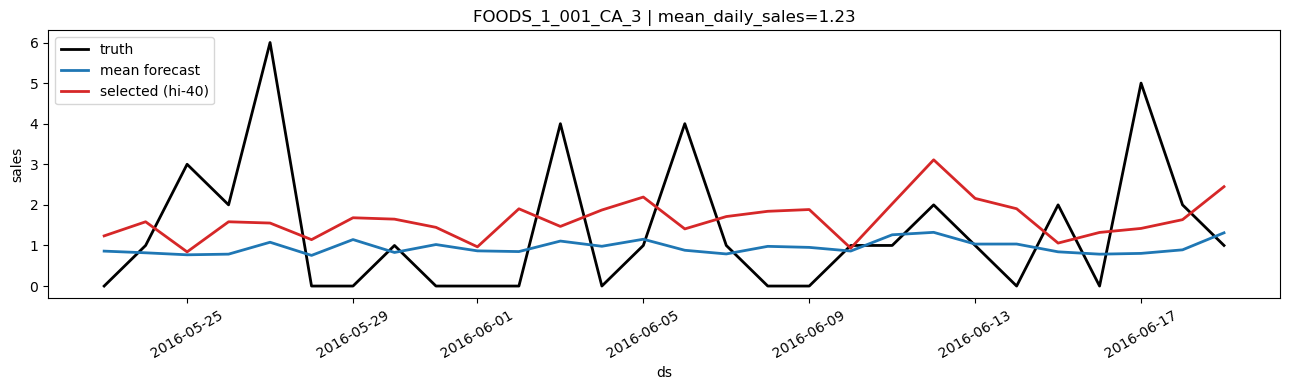

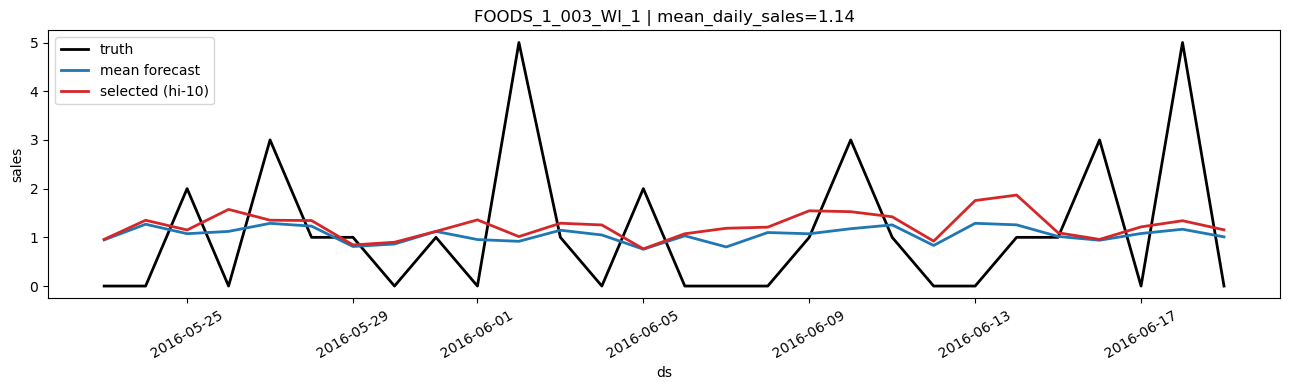

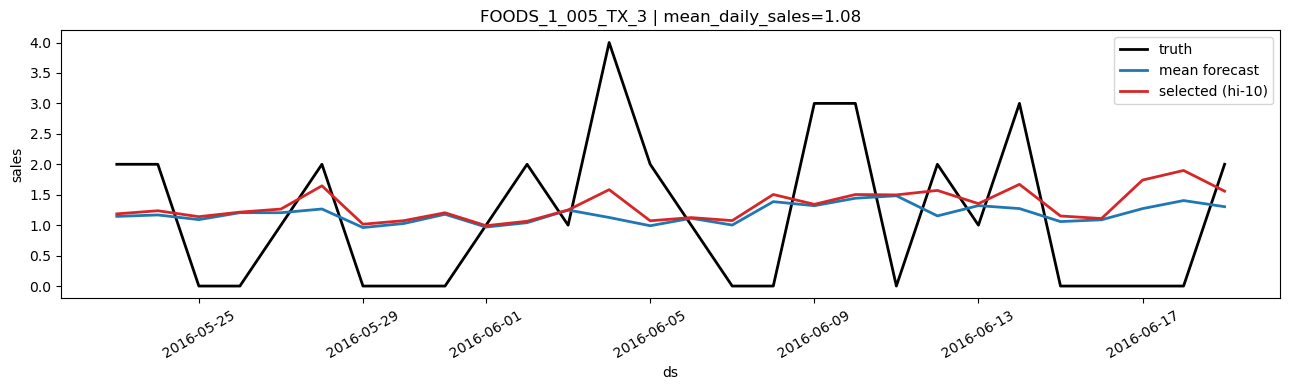

In [22]:
plot_selected_ids(
    eval_df=test_eval,
    selector=selector_df,
    rank_stats=selected_rank_stats,
    model_col=MODEL_NAME,
    plot_n=PLOT_N_IDS,
)
